# MACE / ab-initio trajectory energy matching

Compare active-state MACE potential energies with ab-initio reference energies at identical geometries. The analysis deliberately stops when the paired trajectories do not share the same geometry.

## 1. Read data

In [49]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np

# Paths are relative to the repository root.
mace_trajs_folder = Path("ethene_02_dynamic_first/traj-allmols/Singlet_1")
ab_initio_trajs_folder = Path("casscf_ethene_02_dynamic_first")


def trajectory_id(path: Path) -> int:
    match = re.fullmatch(r"TRAJ_(\d+)", path.name)
    if match is None:
        raise ValueError(f"Not a trajectory directory: {path}")
    return int(match.group(1))


def discover_trajectories(folder: Path) -> dict[int, Path]:
    if not folder.is_dir():
        raise FileNotFoundError(f"Trajectory folder does not exist: {folder}")
    trajectories = {trajectory_id(path): path for path in folder.glob("TRAJ_*") if path.is_dir()}
    if not trajectories:
        raise ValueError(f"No TRAJ_* subfolders found in {folder}")
    return dict(sorted(trajectories.items()))


mace_traj_by_id = discover_trajectories(mace_trajs_folder)
ab_initio_traj_by_id = discover_trajectories(ab_initio_trajs_folder)

# Public lists requested for the two trajectory roots, in numeric TRAJ_* order.
mace_trajs = list(mace_traj_by_id.values())
ab_initio_trajs = list(ab_initio_traj_by_id.values())

common_traj_ids = sorted(mace_traj_by_id.keys() & ab_initio_traj_by_id.keys())
missing_mace_ids = sorted(ab_initio_traj_by_id.keys() - mace_traj_by_id.keys())
missing_ab_initio_ids = sorted(mace_traj_by_id.keys() - ab_initio_traj_by_id.keys())
if missing_mace_ids or missing_ab_initio_ids:
    raise ValueError(
        f"Unpaired trajectories; missing MACE: {missing_mace_ids}, "
        f"missing ab-initio: {missing_ab_initio_ids}"
    )

print(f"Found {len(mace_trajs)} MACE and {len(ab_initio_trajs)} ab-initio trajectories.")


Found 100 MACE and 100 ab-initio trajectories.


## 2. Functions

In [44]:
HARTREE_TO_EV = 27.211386245988
min_threshold = 0.05  # eV; smaller per-timestep errors do not contribute cumulatively
max_threshold = 0.5  # eV; upper cumulative-error limit for a matched trajectory


def require_file(path: Path) -> Path:
    if not path.is_file() or path.stat().st_size == 0:
        raise FileNotFoundError(f"Missing or empty file: {path}")
    return path


def parse_xyz_frames(path: Path, *, require_ref_energy: bool = False):
    """Read XYZ/extXYZ frames as symbols, coordinates, optional times, and REF_energy arrays."""
    lines = require_file(path).read_text(encoding="utf-8").splitlines()
    frames, cursor = [], 0
    while cursor < len(lines):
        if not lines[cursor].strip():
            cursor += 1
            continue
        try:
            natoms = int(lines[cursor].strip())
        except ValueError as error:
            raise ValueError(f"{path}: expected atom count at line {cursor + 1}") from error
        if natoms <= 0 or cursor + natoms + 1 >= len(lines):
            raise ValueError(f"{path}: incomplete XYZ frame at line {cursor + 1}")
        comment = lines[cursor + 1]
        atom_lines = lines[cursor + 2: cursor + 2 + natoms]
        frame_index = len(frames)
        symbols, coordinates, coordinate_error = [], [], None
        for line in atom_lines:
            fields = line.split()
            if len(fields) < 4:
                coordinate_error = f"malformed atom line: {line!r}"
                break
            symbols.append(fields[0])
            try:
                coordinate = [float(value) for value in fields[1:4]]
            except ValueError:
                coordinate_error = f"non-numeric coordinates in {line!r}"
                break
            if not np.all(np.isfinite(coordinate)):
                coordinate_error = f"non-finite coordinates in {line!r}"
                break
            coordinates.append(coordinate)
        time_match = re.search(r"\bt=\s*([-+0-9.eE]+)", comment)
        energy_match = re.search(r"REF_energy=\"_JSON (.*?)\"", comment)
        if require_ref_energy and energy_match is None:
            raise ValueError(f"{path}: REF_energy missing from frame {len(frames)}")
        ref_energy = None if energy_match is None else np.asarray(json.loads(energy_match.group(1)), dtype=float).squeeze()
        if coordinate_error is not None:
            print(f"Warning: {path}: invalid coordinates at frame {frame_index} ({coordinate_error}); stopping this trajectory before that frame.")
            break
        frames.append({
            "symbols": tuple(symbols),
            "coordinates": np.asarray(coordinates, dtype=float),
            "time_fs": None if time_match is None else float(time_match.group(1)),
            "ref_energy_ev": ref_energy,
        })
        cursor += natoms + 2
    if not frames:
        raise ValueError(f"{path}: no XYZ frames found")
    return frames


def ab_initio_xyz_path(ab_initio_traj: Path) -> Path:
    candidates = sorted(ab_initio_traj.glob("*_CASSCF.xyz"))
    if len(candidates) != 1:
        raise FileNotFoundError(f"{ab_initio_traj}: expected exactly one *_CASSCF.xyz file")
    return candidates[0]


def parse_mace_lis(path: Path):
    """Read step, time, active MCH state, and active potential energy from output.lis."""
    rows = []
    for line in require_file(path).read_text(encoding="utf-8").splitlines():
        fields = line.split()
        if not fields or fields[0].startswith("#"):
            continue
        if len(fields) < 7:
            continue
        try:
            rows.append((int(fields[0]), float(fields[1]), int(fields[3]), float(fields[5])))
        except ValueError:
            continue
    if not rows:
        raise ValueError(f"{path}: no valid output.lis data rows")
    return np.asarray(rows, dtype=float)


def read_ezero_ev(mace_traj: Path) -> float:
    input_path = require_file(mace_traj / "input")
    match = re.search(r"^\s*ezero\s+([-+0-9.eE]+)", input_path.read_text(encoding="utf-8"), re.MULTILINE)
    if match is None:
        raise ValueError(f"{input_path}: ezero not found")
    return float(match.group(1)) * HARTREE_TO_EV


def per_timestep_energy_error(mace_traj: Path, ab_initio_traj: Path) -> tuple[np.ndarray, np.ndarray]:
    """Return MACE times (fs) and absolute active-state potential-energy errors (eV)."""
    mace_frames = parse_xyz_frames(mace_traj / "output.xyz")
    ab_frames = parse_xyz_frames(ab_initio_xyz_path(ab_initio_traj), require_ref_energy=True)
    lis = parse_mace_lis(mace_traj / "output.lis")
    common_frame_count = min(len(lis), len(mace_frames), len(ab_frames))
    if len(lis) != len(mace_frames):
        print(
            f"Warning: {mace_traj.name}: output.lis has {len(lis)} rows but output.xyz has "
            f"{len(mace_frames)} frames; using the first {common_frame_count} paired frame(s)."
        )
    if common_frame_count == 0:
        return np.asarray([], dtype=float), np.asarray([], dtype=float)
    lis = lis[:common_frame_count]
    mace_frames = mace_frames[:common_frame_count]
    ab_frames = ab_frames[:common_frame_count]
    times = lis[:, 1]
    xyz_times = np.asarray([frame["time_fs"] for frame in mace_frames], dtype=float)
    if np.any(np.isnan(xyz_times)) or not np.allclose(times, xyz_times, rtol=0, atol=1e-8):
        raise ValueError(f"{mace_traj.name}: output.xyz and output.lis times do not match")
    active_states = lis[:, 2].astype(int)
    reference_energies = np.asarray([frame["ref_energy_ev"] for frame in ab_frames], dtype=float)
    if reference_energies.ndim != 2:
        raise ValueError(f"{ab_initio_traj.name}: REF_energy must contain one energy per electronic state")
    if np.any(active_states < 1) or np.any(active_states > reference_energies.shape[1]):
        raise ValueError(f"{mace_traj.name}: active MCH state is outside REF_energy bounds")
    ab_active_potential = reference_energies[np.arange(len(times)), active_states - 1] - read_ezero_ev(mace_traj)
    return times, np.abs(lis[:, 3] - ab_active_potential)


def cumulative_energy_error(
    mace_traj: Path, ab_initio_traj: Path, threshold: float = min_threshold
) -> tuple[np.ndarray, np.ndarray]:
    """Return time and cumulative error, excluding per-timestep errors below ``threshold`` eV."""
    if threshold < 0:
        raise ValueError("threshold must be non-negative")
    times, errors = per_timestep_energy_error(mace_traj, ab_initio_traj)
    included_errors = np.where(errors >= threshold, errors, 0.0)
    return times, np.cumsum(included_errors)


def max_match_duration(
    mace_traj: Path, ab_initio_traj: Path, threshold: float = max_threshold
) -> float:
    """Return the duration (fs) through the last frame with cumulative error below ``threshold``."""
    if threshold < 0:
        raise ValueError("threshold must be non-negative")
    times, cumulative_error = cumulative_energy_error(mace_traj, ab_initio_traj)
    matching_indices = np.flatnonzero(cumulative_error < threshold)
    if matching_indices.size == 0:
        return 0.0
    return float(times[matching_indices[-1]] - times[0])


## 3. Plots

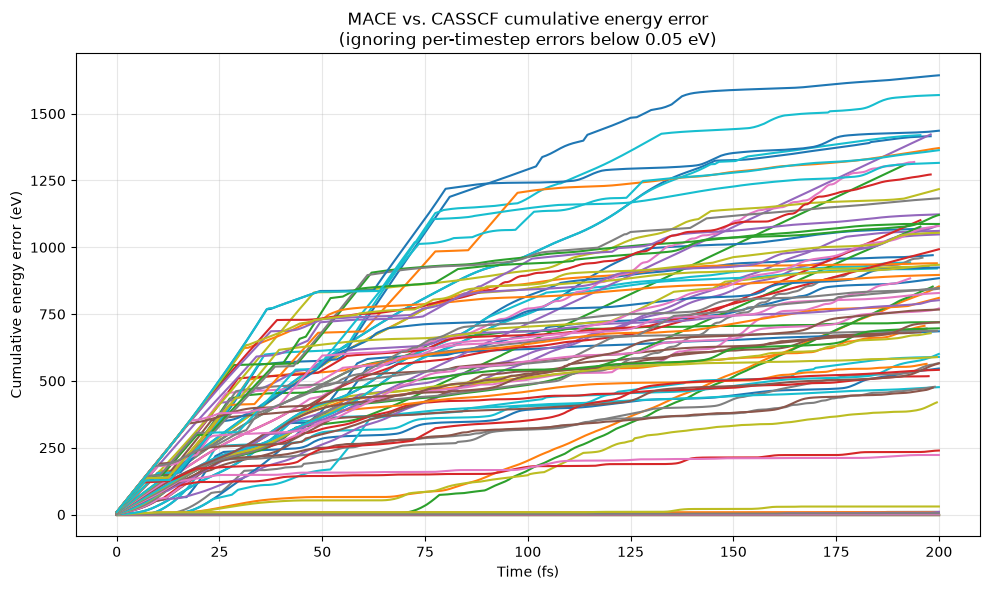

In [45]:
trajectory_ids_to_plot = range(1, 101)

# Build every requested pair. Geometry diagnostics are printed during the calculation.
requested_pairs = []
for traj_id in trajectory_ids_to_plot:
    if traj_id not in mace_traj_by_id or traj_id not in ab_initio_traj_by_id:
        raise KeyError(f"TRAJ_{traj_id:05d} is missing from one of the input folders")
    mace_traj = mace_traj_by_id[traj_id]
    ab_initio_traj = ab_initio_traj_by_id[traj_id]
    requested_pairs.append((traj_id, mace_traj, ab_initio_traj))

fig, ax = plt.subplots(figsize=(10, 6))
for traj_id, mace_traj, ab_initio_traj in requested_pairs:
    time_fs, cumulative_error_ev = cumulative_energy_error(mace_traj, ab_initio_traj)
    ax.plot(time_fs, cumulative_error_ev, label=f"TRAJ_{traj_id:05d}")

ax.set_xlabel("Time (fs)")
ax.set_ylabel("Cumulative energy error (eV)")
ax.set_title(f"MACE vs. CASSCF cumulative energy error\n(ignoring per-timestep errors below {min_threshold:g} eV)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


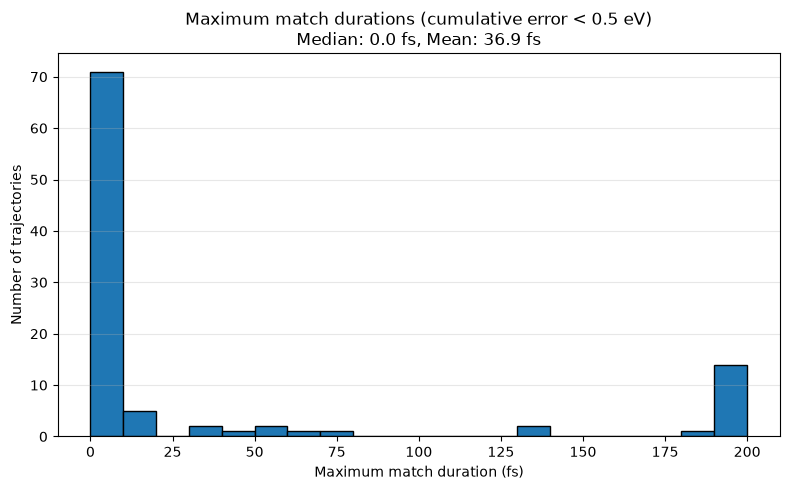

In [46]:

match_durations_fs = np.asarray([
    max_match_duration(mace_traj, ab_initio_traj)
    for _, mace_traj, ab_initio_traj in requested_pairs
])

fig_hist, ax_hist = plt.subplots(figsize=(8, 5))
ax_hist.hist(match_durations_fs, bins=20, edgecolor="black")
ax_hist.set_xlabel("Maximum match duration (fs)")
ax_hist.set_ylabel("Number of trajectories")
ax_hist.set_title(f"Maximum match durations (cumulative error < {max_threshold:g} eV)\nMedian: {np.median(match_durations_fs):.1f} fs, Mean: {np.mean(match_durations_fs):.1f} fs")
ax_hist.grid(axis="y", alpha=0.3)
fig_hist.tight_layout()
plt.show()


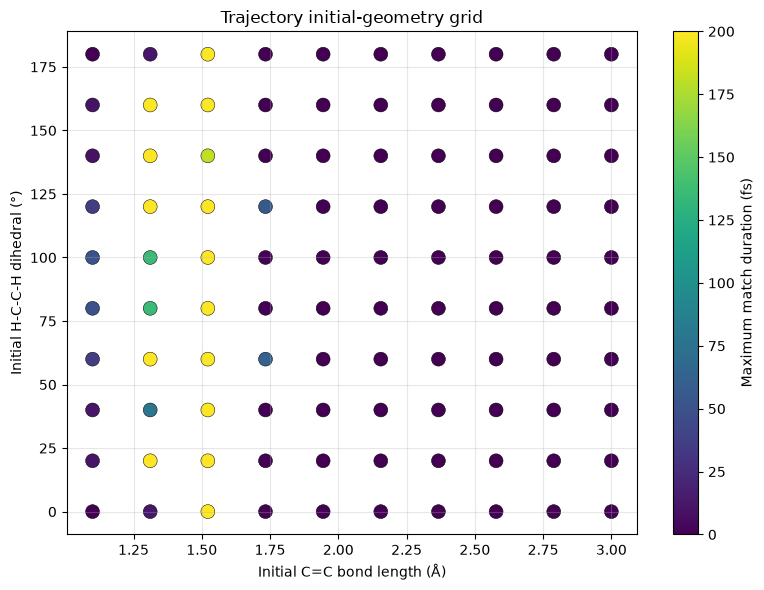

In [48]:
# Initial-geometry map: each square is one trajectory, coloured by maximum match duration.
def initial_cc_hcch(mace_traj: Path) -> tuple[float, float]:
    """Return the initial C=C distance (Å) and absolute H-C-C-H torsion (degrees)."""
    initial_frame = parse_xyz_frames(mace_traj / "output.xyz")[0]
    symbols = initial_frame["symbols"]
    coordinates = initial_frame["coordinates"]
    carbons = [index for index, symbol in enumerate(symbols) if symbol == "C"]
    hydrogens = [index for index, symbol in enumerate(symbols) if symbol == "H"]
    if len(carbons) < 2 or len(hydrogens) < 2:
        raise ValueError("initial frame needs at least two C atoms and two H atoms")
    carbon_a, carbon_b = min(
        ((i, j) for i in carbons for j in carbons if i < j),
        key=lambda pair: np.linalg.norm(coordinates[pair[0]] - coordinates[pair[1]]),
    )
    hydrogen_a = min(hydrogens, key=lambda index: np.linalg.norm(coordinates[index] - coordinates[carbon_a]))
    hydrogen_b = min(hydrogens, key=lambda index: np.linalg.norm(coordinates[index] - coordinates[carbon_b]))
    p0, p1, p2, p3 = coordinates[[hydrogen_a, carbon_a, carbon_b, hydrogen_b]]
    b0, b1, b2 = -(p1 - p0), p2 - p1, p3 - p2
    b1 /= np.linalg.norm(b1)
    v, w = b0 - np.dot(b0, b1) * b1, b2 - np.dot(b2, b1) * b1
    if np.linalg.norm(v) == 0 or np.linalg.norm(w) == 0:
        raise ValueError("initial H-C-C-H torsion is undefined")
    torsion = np.degrees(np.arctan2(np.dot(np.cross(b1, v), w), np.dot(v, w)))
    return float(np.linalg.norm(p1 - p2)), float(abs((torsion + 180) % 360 - 180))


initial_geometry_records = []
for (trajectory_id, mace_traj, _), duration_fs in zip(requested_pairs, match_durations_fs):
    try:
        cc_bond_angstrom, hcch_dihedral_deg = initial_cc_hcch(mace_traj)
    except ValueError as error:
        print(f"Warning: TRAJ_{trajectory_id:05d}: omitted from initial-geometry grid ({error}).")
        continue
    initial_geometry_records.append((trajectory_id, cc_bond_angstrom, hcch_dihedral_deg, duration_fs))

initial_geometry = np.asarray(initial_geometry_records, dtype=float)
if initial_geometry.size == 0:
    raise ValueError("No trajectories have a plottable initial C=C / H-C-C-H geometry")

fig_grid, ax_grid = plt.subplots(figsize=(8, 6))
points = ax_grid.scatter(
    initial_geometry[:, 1], initial_geometry[:, 2], c=initial_geometry[:, 3],
    cmap="viridis", s=100, edgecolors="black", linewidths=0.35,
)
colorbar = fig_grid.colorbar(points, ax=ax_grid)
colorbar.set_label("Maximum match duration (fs)")
ax_grid.set_xlabel("Initial C=C bond length (Å)")
ax_grid.set_ylabel("Initial H-C-C-H dihedral (°)")
ax_grid.set_title("Trajectory initial-geometry grid")
ax_grid.grid(alpha=0.3)
fig_grid.tight_layout()
plt.show()
